In [3]:
import os
import sys
import numpy as np
from gen_graph import gen_plots

# custom imports
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from iir_host import train_iir
from data_proc.parse_audio_data import parse_audio, save_audio

import pickle
import matplotlib.pyplot as plt

N = 30000
with open("../data/train_set.pickle", "rb") as f:
    train_set = pickle.load(f)

with open("../data/test_set.pickle", "rb") as f:
    test_set = pickle.load(f)

train_x = [i[0] for i in train_set]
train_y = [i[1] for i in train_set]

fwd_weights, back_weights, loss_hist = train_iir(train_x, train_y, N, epochs=100)


Reverse differentiation of function rev_iir_loss:
def rev_iir_loss(noisy : In[Array[float]], _dnoisy_IA8brp : Out[Array[float]], clean : In[Array[float]], _dclean_f8z01y : Out[Array[float]], out_sig : In[Array[float]], _dout_sig_AKXWAd : Out[Array[float]], b_weights : In[Array[float]], _db_weights_ttSNTy : Out[Array[float]], a_weights : In[Array[float]], _da_weights_KFaYL7 : Out[Array[float]], N : In[int], _dN_VHuBzf : Out[int], K : In[int], _dK_utGIQD : Out[int], M : In[int], _dM_VpLsT4 : Out[int], _dreturn_2DBAnw : In[float]) -> void:
	_t_float_1m4PhD : Array[float, 1590000]
	_stack_ptr_float_1m4PhD : int = (int)(0)
	_t_int_hwlZC6 : Array[int, 1530000]
	_stack_ptr_int_hwlZC6 : int = (int)(0)
	_loop_var_0_JrBoII : int
	_loop_var_1_78iEFK : int
	_loop_var_1_78iEFK_stack : Array[int, 30000]
	_loop_var_1_78iEFK_stack_ptr : int
	_loop_var_2_NhrT5N : int
	_loop_var_2_NhrT5N_stack : Array[int, 30000]
	_loop_var_2_NhrT5N_stack_ptr : int
	loss : float = (float)(0.0)
	_dloss_kL8a3b : float
	i

training...:   1%|          | 1/100 [00:01<02:52,  1.74s/it]

Epoch 0 | Loss: 134.5770


training...:  11%|█         | 11/100 [00:19<02:35,  1.74s/it]

Epoch 10 | Loss: 84.5065


...

Epoch 80 | Loss: 83.8401


training...:  91%|█████████ | 91/100 [02:37<00:15,  1.72s/it]

Epoch 90 | Loss: 84.3202


training...: 100%|██████████| 100/100 [02:52<00:00,  1.73s/it]

final loss: 83.98719856392253


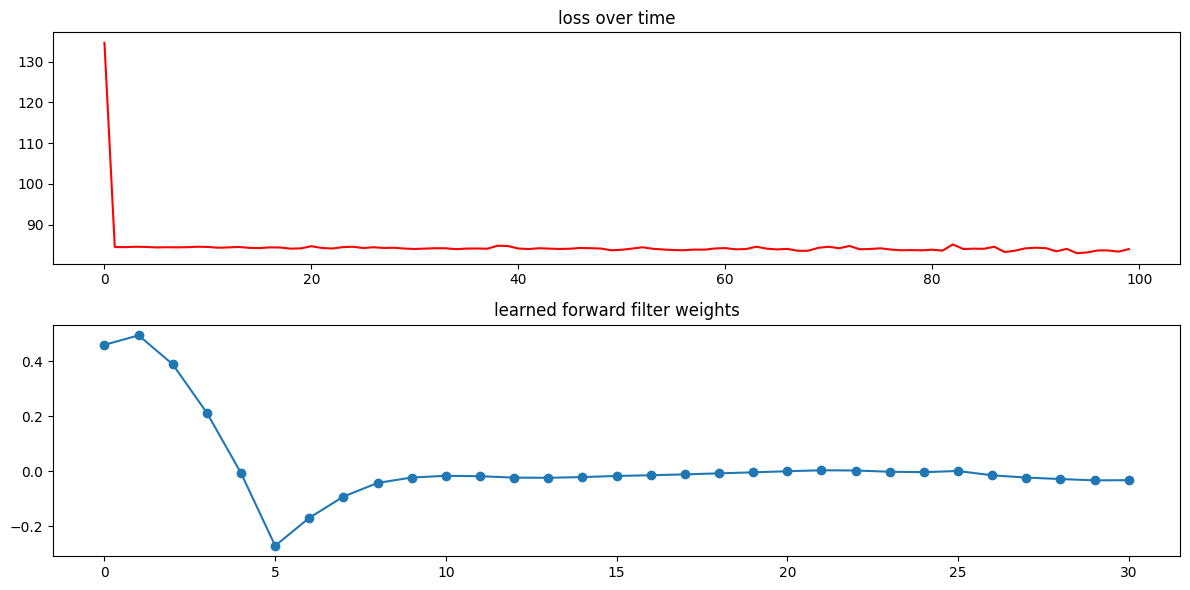

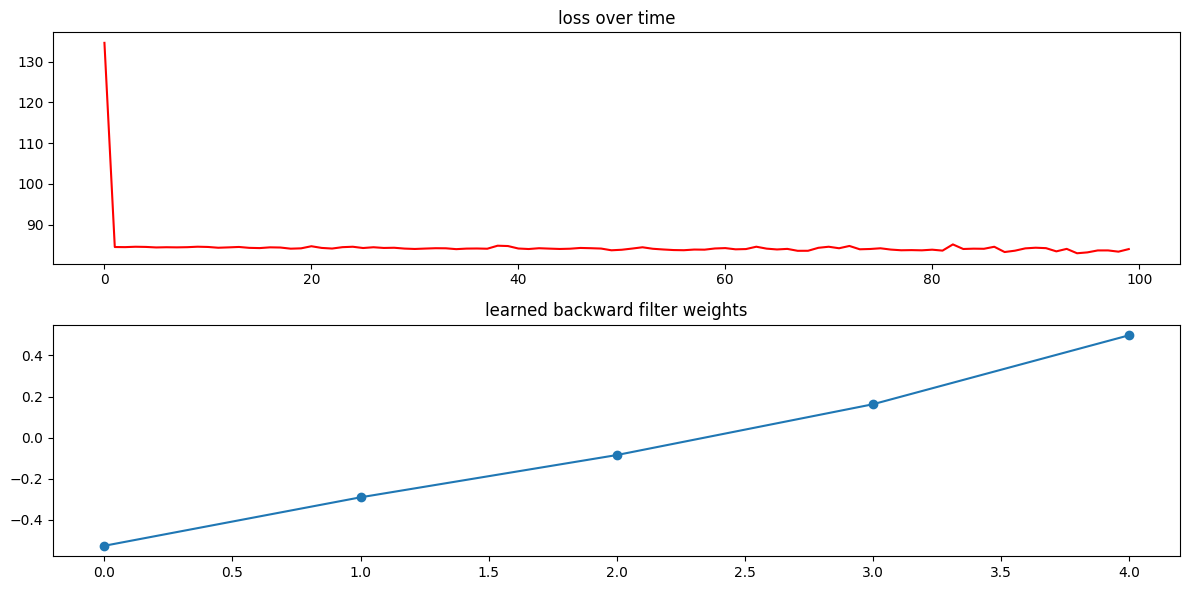

In [4]:
gen_plots(fwd_weights, loss_hist, "learned forward filter weights")
gen_plots(back_weights, loss_hist, "learned backward filter weights")

saved audio to: ../data/iir_generated1.wav


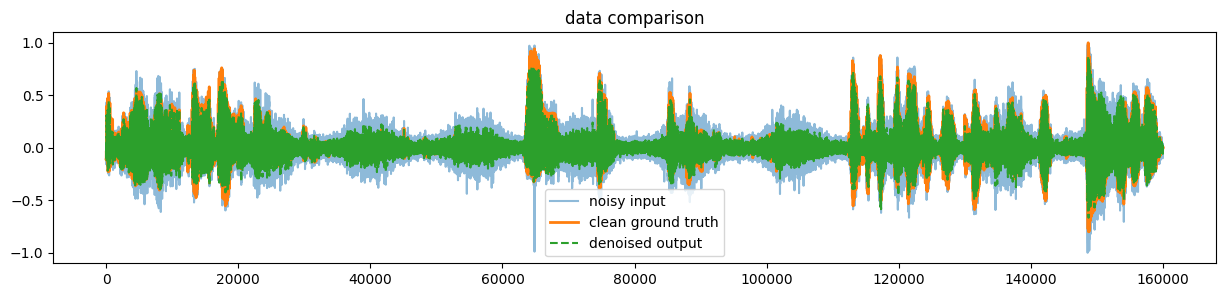

In [ ]:
import random

# peak at some samples
def peak_sample_perf(noisy_sample, clean_sample, weights):
    plt.figure(figsize=(15, 3))
    # example for one data snippet
    b_weights, a_weights = weights
    denoised_audio = np.zeros_like(noisy_sample, dtype=np.float32)
    K = len(b_weights)
    M = len(a_weights)

    for i in range(len(noisy_sample)):
        sum_b = 0.0
        for j in range(min(K, i + 1)):
            sum_b += noisy_sample[i - j] * b_weights[j]

        sum_a = 0.0
        for m in range(min(M, i)):
            sum_a += denoised_audio[i - 1 - m] * a_weights[m]

        denoised_audio[i] = sum_b + sum_a

    save_audio(denoised_audio, 16000, output_path="../data/generated/iir.wav")

    plt.title("data comparison")
    plt.plot(noisy_sample, label="noisy input", alpha=0.5)
    plt.plot(clean_sample, label="clean ground truth", linewidth=2)
    plt.plot(denoised_audio, label="denoised output", linestyle='--')
    plt.legend()

    plt.show()

test_x = [i[0] for i in test_set]
test_y = [i[1] for i in test_set]

noise = f"../data/noise_speech_data/british_accent_70.wav"
clean = f"../data/speech_data/british_accent_70.wav"

noise, clean = parse_audio(clean, noise, max_n=None)

peak_sample_perf(noise, clean, (fwd_weights, back_weights))

In [9]:
# calc average test set MSE
def calc_loss(eval_x, eval_y, weights, K=31):
    total_mse = 0.0
    for x, y in zip(eval_x, eval_y):
        b_weights, a_weights = weights
        denoised_audio = np.zeros_like(x, dtype=np.float32)
        K = len(b_weights)
        M = len(a_weights)

        for i in range(len(x)):
            sum_b = 0.0
            for j in range(min(K, i + 1)):
                sum_b += x[i - j] * b_weights[j]

            sum_a = 0.0
            for m in range(min(M, i)):
                sum_a += denoised_audio[i - 1 - m] * a_weights[m]

            denoised_audio[i] = sum_b + sum_a

        valid_denoised = denoised_audio[K-1 : len(x)]
        valid_y = y[K-1 : len(x)]
        
        mse = np.sum((valid_denoised - valid_y) ** 2)
        total_mse += mse

    # Return the average MSE across all files in the dataset
    return total_mse / len(eval_x)

print(calc_loss(test_x, test_y, (fwd_weights, back_weights)))
print(calc_loss(train_x, train_y, (fwd_weights, back_weights)))

97.82197
82.625534
